<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/lecture_notebooks/lecture%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

unnormalized_probs = [
    [0,0,1,1,4,2,1,1],
    [0,1,2,4,6,4,2,1],
    [0,0,1,1,4,2,1,0],
    [1,1,1,1,1,1,1,1],
    [2,3,2,1,0,0,0,0],
    [1,2,1,0,0,0,1,1],
    [5,4,3,2,1,0,1,2],
]

probs = np.array( unnormalized_probs ) / np.sum( unnormalized_probs )


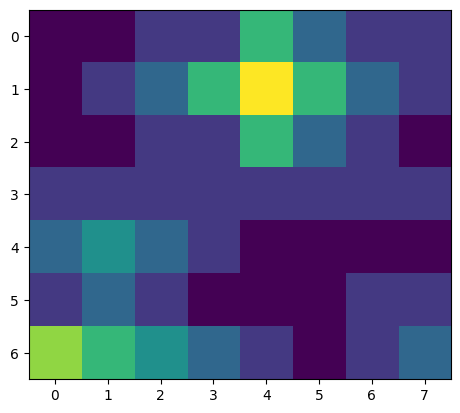

In [ ]:
plt.imshow( probs )

In [ ]:
#
# NOTES:
#
#   Use np.log (ie, the natural logarithm -- don't worry about using base 2 logs)
#   x and y are zero-indexed
#

In [ ]:
# compute the marginal distributions p(x) and p(y)
px = np.sum( probs, axis=1, keepdims=True )
py = np.sum( probs, axis=0, keepdims=True )
print( px.shape )
print( py.shape )

(7, 1)
(1, 8)


In [ ]:
# compute the kl divergence KL( p(x,y) || p(x)p(y) )  -- Eq. 6.47
def kl(q,p):
  return np.sum( q * np.log( q+1e-100 ) - q * np.log(p+1e-100) )
kl( probs, np.dot(px,py) )

0.35381733502971546

In [ ]:
# compute the entropy H(X) -- eq. 6.1
def H(p):
  return -np.sum( p * np.log(p+1e-100) )
print( H(px) )

1.85344999523382


In [ ]:
# compute the entropy H(Y)
print( H(py) )

2.0395372608448876


In [ ]:
# compute the entropy H(X|y=1) -- x and y are zero indexed
cond = probs[ :, 1 ]
print(np.sum(cond))
cond = cond / np.sum(cond)
print( H(cond) )

0.13924050632911392
1.4681399390162087


In [ ]:
# compute the entropy H(Y|x=3)
cond = probs[ 3, : ]
print(np.sum(cond))
cond = cond / np.sum(cond)
print( H(cond) )

0.10126582278481013
2.0794415416798357


In [ ]:
# compute the entropy H(X|Y) -- use eq. 6.11 or 6.12, do NOT use the simpler eq. 6.15 :)
cond = probs / np.sum( probs, axis=0, keepdims=True )
colwise_entropy = -np.sum( cond * np.log(cond+1e-100), axis=0 )
HXY = np.sum( colwise_entropy * py )
print( HXY )

[1.1490597  1.46813994 1.84622022 1.60943791 1.40753174 1.27302834
 1.7478681  1.56071041]
1.4996326602041046


In [ ]:
# compute the entropy H(Y|X)
cond = probs / np.sum( probs, axis=1, keepdims=True )
print(np.sum(cond,axis=1))
colwise_entropy = -np.sum( cond * np.log(cond+1e-20), axis=1 )
HYX = np.sum( colwise_entropy * px )
print( HYX )

[1. 1. 1. 1. 1. 1. 1.]
11.560702004535285


In [ ]:
# compute the mutual information 3 times, using eq. 6.49, 6.50, and 6.51 (ie, calculate the intermediate terms)